In [1]:
import logging
import random
import string
from pathlib import Path

import nltk
import numpy as np
import matplotlib.pyplot as plt

from nltk.corpus import brown, stopwords
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

# Watch gensim's internal training progress
logging.basicConfig(
    format="%(asctime)s : %(levelname)s : %(message)s",
    level=logging.INFO,
)

# Reproducibility — same seed everywhere
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [ ]:
for resource in ["brown", "stopwords"]:
    try:
        nltk.data.find(f"corpora/{resource}")
    except LookupError:
        nltk.download(resource, quiet=True)

In [3]:
STOPWORDS = set(stopwords.words("english"))
PUNCT = set(string.punctuation)


def preprocess(sentence: list[str]) -> list[str]:
    """Lowercase, drop stopwords, punctuation, non-alpha, and short tokens."""
    return [
        tok.lower()
        for tok in sentence
        if tok.lower() not in STOPWORDS
        and tok not in PUNCT
        and len(tok) > 2
        and tok.isalpha()
    ]


raw_sentences = brown.sents()                       # ~57K tokenized sentences
sentences = [preprocess(s) for s in raw_sentences]
sentences = [s for s in sentences if len(s) > 1]    # drop empty / 1-token sentences

print(f"Total sentences: {len(sentences):,}")
print(f"Total tokens:    {sum(len(s) for s in sentences):,}")
print(f"Sample sentence: {sentences[0][:10]}")

Total sentences: 53,866
Total tokens:    502,844
Sample sentence: ['fulton', 'county', 'grand', 'jury', 'said', 'friday', 'investigation', 'recent', 'primary', 'election']


In [4]:
W2V_PARAMS = dict(
    vector_size=100,   # embedding dimension
    window=5,          # context radius
    min_count=5,       # drop words seen < 5 times
    workers=4,         # parallel threads
    epochs=10,         # passes over corpus
    negative=10,       # negative sampling count
    sample=1e-3,       # downsample frequent words
    seed=SEED,
)

In [5]:
print("=== Training CBOW ===")
cbow_model = Word2Vec(sentences=sentences, sg=0, **W2V_PARAMS)
print(f"Vocab size: {len(cbow_model.wv.index_to_key):,}")

2026-06-15 14:48:52,592 : INFO : collecting all words and their counts
2026-06-15 14:48:52,594 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-06-15 14:48:52,618 : INFO : PROGRESS: at sentence #10000, processed 103033 words, keeping 18231 word types
2026-06-15 14:48:52,647 : INFO : PROGRESS: at sentence #20000, processed 201191 words, keeping 25911 word types
2026-06-15 14:48:52,676 : INFO : PROGRESS: at sentence #30000, processed 311312 words, keeping 31591 word types
2026-06-15 14:48:52,701 : INFO : PROGRESS: at sentence #40000, processed 407822 words, keeping 36007 word types
2026-06-15 14:48:52,721 : INFO : PROGRESS: at sentence #50000, processed 475293 words, keeping 38756 word types
2026-06-15 14:48:52,730 : INFO : collected 39883 word types from a corpus of 502844 raw words and 53866 sentences
2026-06-15 14:48:52,731 : INFO : Creating a fresh vocabulary
2026-06-15 14:48:52,776 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 retain

=== Training CBOW ===


2026-06-15 14:48:52,777 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 leaves 456915 word corpus (90.87% of original 502844, drops 45929)', 'datetime': '2026-06-15T14:48:52.777910', 'gensim': '4.3.3', 'python': '3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26200-SP0', 'event': 'prepare_vocab'}
2026-06-15 14:48:52,833 : INFO : deleting the raw counts dictionary of 39883 items
2026-06-15 14:48:52,834 : INFO : sample=0.001 downsamples 11 most-common words
2026-06-15 14:48:52,835 : INFO : Word2Vec lifecycle event {'msg': 'downsampling leaves estimated 452280.4574264008 word corpus (99.0%% of prior 456915)', 'datetime': '2026-06-15T14:48:52.835146', 'gensim': '4.3.3', 'python': '3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26200-SP0', 'event': 'prepare_vocab'}
2026-06-15 14:48:52,913 : INFO : estimated required 

Vocab size: 13,121


In [7]:
print("=== Training Skip-gram ===")
sg_model = Word2Vec(sentences=sentences, sg=1, **W2V_PARAMS)
print(f"Vocab size: {len(sg_model.wv.index_to_key):,}")

2026-06-15 14:51:02,136 : INFO : collecting all words and their counts
2026-06-15 14:51:02,137 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-06-15 14:51:02,173 : INFO : PROGRESS: at sentence #10000, processed 103033 words, keeping 18231 word types
2026-06-15 14:51:02,207 : INFO : PROGRESS: at sentence #20000, processed 201191 words, keeping 25911 word types
2026-06-15 14:51:02,252 : INFO : PROGRESS: at sentence #30000, processed 311312 words, keeping 31591 word types
2026-06-15 14:51:02,303 : INFO : PROGRESS: at sentence #40000, processed 407822 words, keeping 36007 word types


=== Training Skip-gram ===


2026-06-15 14:51:02,327 : INFO : PROGRESS: at sentence #50000, processed 475293 words, keeping 38756 word types
2026-06-15 14:51:02,337 : INFO : collected 39883 word types from a corpus of 502844 raw words and 53866 sentences
2026-06-15 14:51:02,338 : INFO : Creating a fresh vocabulary
2026-06-15 14:51:02,385 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 retains 13121 unique words (32.90% of original 39883, drops 26762)', 'datetime': '2026-06-15T14:51:02.385667', 'gensim': '4.3.3', 'python': '3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26200-SP0', 'event': 'prepare_vocab'}
2026-06-15 14:51:02,387 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=5 leaves 456915 word corpus (90.87% of original 502844, drops 45929)', 'datetime': '2026-06-15T14:51:02.386674', 'gensim': '4.3.3', 'python': '3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (

Vocab size: 13,121


In [8]:
def compare_similar(query_word: str, topn: int = 5) -> None:
    """Print most-similar words from CBOW and Skip-gram side-by-side."""
    if query_word not in cbow_model.wv:
        print(f"'{query_word}' not in vocabulary — skipping.")
        return

    cbow_sim = cbow_model.wv.most_similar(query_word, topn=topn)
    sg_sim   = sg_model.wv.most_similar(query_word,   topn=topn)

    print(f"\n--- Most similar to '{query_word}' ---")
    print(f"{'CBOW':<30}{'Skip-gram'}")
    print("-" * 60)
    for (w1, s1), (w2, s2) in zip(cbow_sim, sg_sim):
        print(f"{w1:<15}{s1:.3f}        {w2:<15}{s2:.3f}")


for word in ["money", "war", "music", "computer", "school"]:
    compare_similar(word)


--- Most similar to 'money' ---
CBOW                          Skip-gram
------------------------------------------------------------
probably       0.861        sell           0.800
job            0.836        yow            0.770
buy            0.828        debts          0.747
likely         0.823        buying         0.745
otherwise      0.817        buy            0.743

--- Most similar to 'war' ---
CBOW                          Skip-gram
------------------------------------------------------------
europe         0.774        civil          0.641
civil          0.771        wars           0.611
western        0.754        battle         0.605
peace          0.739        custer         0.598
nation         0.730        regiment       0.595

--- Most similar to 'music' ---
CBOW                          Skip-gram
------------------------------------------------------------
style          0.887        jazz           0.797
plays          0.886        musical        0.783
musical     

In [9]:
def analogy(positive: list[str], negative: list[str], model: Word2Vec, topn: int = 3):
    """Return the top-N words for: sum(positive) - sum(negative)."""
    try:
        return model.wv.most_similar(positive=positive, negative=negative, topn=topn)
    except KeyError as e:
        return f"Word not in vocab: {e}"


print("king - man + woman  (CBOW):     ", analogy(["king", "woman"], ["man"], cbow_model))
print("king - man + woman  (Skip-gram):", analogy(["king", "woman"], ["man"], sg_model))

king - man + woman  (CBOW):      [('golf', 0.9336324334144592), ('dated', 0.917619526386261), ('younger', 0.9122640490531921)]
king - man + woman  (Skip-gram): [('arnold', 0.7444252371788025), ('shelley', 0.7410813570022583), ('hymn', 0.7346053719520569)]


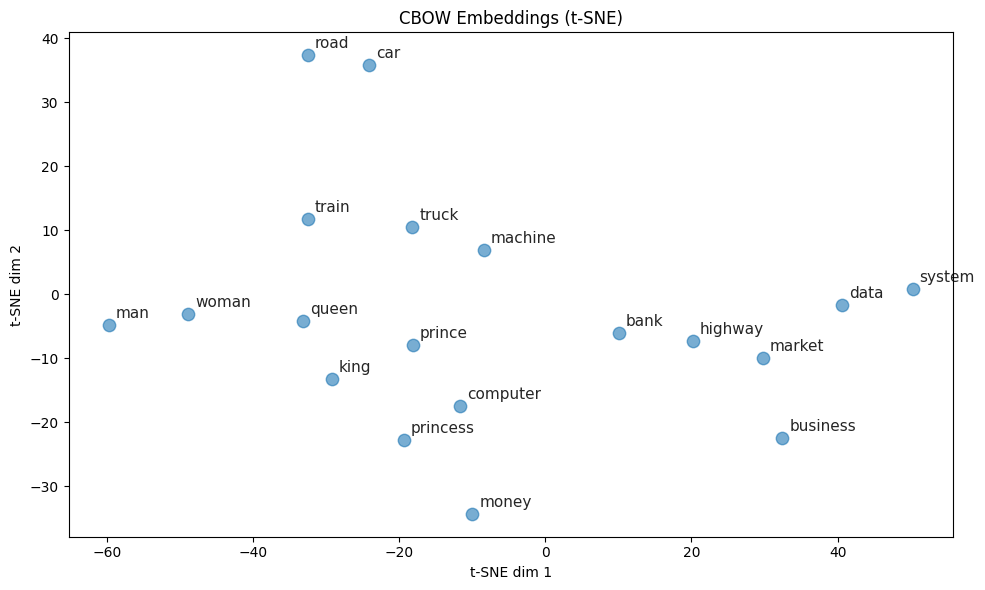

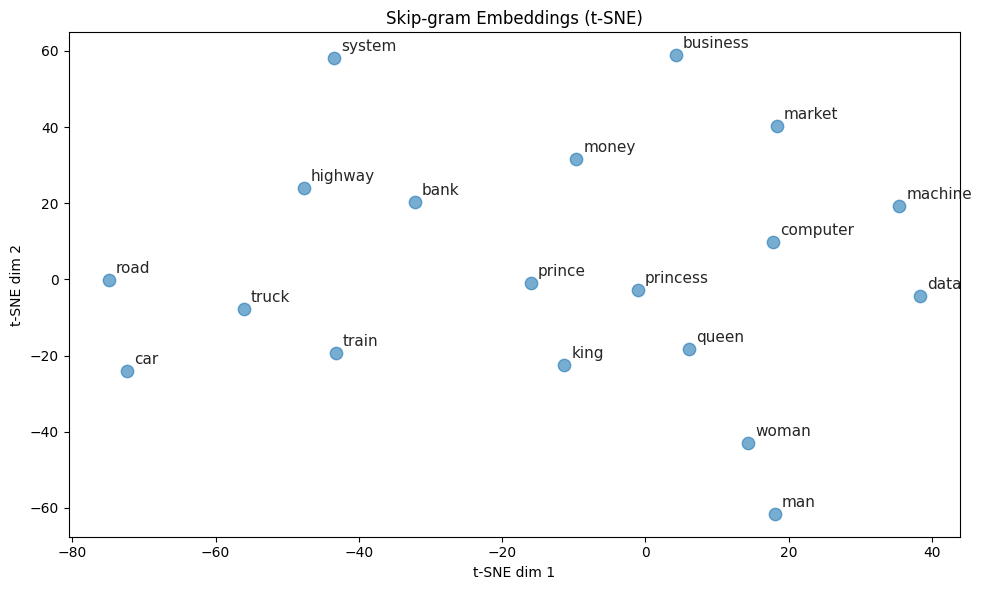

In [10]:
def plot_embeddings(model: Word2Vec, words: list[str], title: str) -> None:
    """Project word vectors to 2D with t-SNE and scatter-plot them."""
    words = [w for w in words if w in model.wv]
    vecs = np.array([model.wv[w] for w in words])

    tsne = TSNE(
        n_components=2,
        random_state=SEED,
        perplexity=min(5, len(words) - 1),
        init="pca",
    )
    coords = tsne.fit_transform(vecs)

    plt.figure(figsize=(10, 6))
    plt.scatter(coords[:, 0], coords[:, 1], alpha=0.6, s=80)
    for word, (x, y) in zip(words, coords):
        plt.annotate(word, (x, y), fontsize=11, alpha=0.85,
                     xytext=(5, 5), textcoords="offset points")
    plt.title(title)
    plt.xlabel("t-SNE dim 1"); plt.ylabel("t-SNE dim 2")
    plt.tight_layout(); plt.show()


target_words = [
    "king", "queen", "man", "woman", "prince", "princess",
    "car", "truck", "road", "highway", "train",
    "computer", "machine", "data", "system",
    "money", "bank", "business", "market",
]
plot_embeddings(cbow_model, target_words, "CBOW Embeddings (t-SNE)")
plot_embeddings(sg_model,   target_words, "Skip-gram Embeddings (t-SNE)")